# CareAI March 2026 — HAN++ Training
## 8-Disease Binary Multi-Label Classification

**Model:** HANPP_Disease (HAN++ with Patient-Conditioned Semantic Attention — the novel contribution)  
**Task:** Predict 8 binary disease labels per patient  
**Diseases:** Anemia · CKD · Diabetes · Dyslipidemia · Electrolyte_Imbalance · Hematology_Disorder · Liver_Disease · Thyroid_Disorder  
*(Infection_Inflammation excluded — 0 positive patients in the dataset)*  
*(Cardiovascular excluded — no unique organ mapping separate from Dyslipidemia)*

**Dataset:** `data/dataset_careai_March/`  (95,836 patients)  
**Outputs:** `output/careai_march/`  ·  `models_saved/careai_march/`

---

### What is novel about the model?

Standard HAN uses a **global** semantic attention query shared by all patients.
HAN++ replaces this with a **patient-specific** query:
```
q_i = W_q · h_i          (each patient computes its own query)
β_ik = softmax(q_i^T · tanh(W_sem · z_i^Φk))   over meta-paths k
```
This means different patients can attend to different meta-paths — a diabetic patient
relies more on P-D-P (disease co-occurrence), while a CKD patient relies more on P-O-P
(organ similarity). This is baked into every forward pass during training.

MC Dropout and Interpretability are post-training analysis tools (run after training is done).

## 1. Imports & Configuration

In [1]:
import os
import sys
import json
import time
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score, classification_report
)
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

# Ensure we run from project root so HAN package is importable
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from HAN import MedicalGraphData
from HAN.model import HANPP_Disease

print(f"Working directory : {os.getcwd()}")
print(f"PyTorch           : {torch.__version__}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device            : {DEVICE}")

Working directory : /Users/charlie/Documents/Coding/VS Code/Language_python/FYP/New_2026/HAN-implementation
PyTorch           : 2.8.0
Device            : cpu


In [ ]:

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR   = 'data/dataset_careai_March'
PROC_DIR   = 'data/dataset_careai_March/processed'
OUTPUT_DIR = 'output/careai_march'
MODEL_DIR  = 'models_saved/careai_march'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,  exist_ok=True)

# ── Disease labels (v6: 95,836 patients, 8 diseases) ──────────────────────────
# Infection_Inflammation excluded — 0 positive patients
# Cardiovascular excluded — no unique organ mapping (cardiovascular_system → Dyslipidemia)
# Thyroid_Disorder included — 8,566 patients (8.9%), good enough
DISEASE_NAMES = [
    'Anemia', 'CKD', 'Diabetes', 'Dyslipidemia',
    'Electrolyte_Imbalance', 'Hematology_Disorder', 'Liver_Disease', 'Thyroid_Disorder'
]

# ── Organ → disease mapping (expanded for v6 dataset) ────────────────────────
# Used by preprocess_data() to build test_reference_full_v2.csv
# NOTE: 'inflammatory_system' → 'Infection_Inflammation' intentionally omitted (0 positives)
ORGAN_TO_DISEASE = {
    'pancreas':                               'Diabetes',
    'pancrese':                               'Diabetes',
    'cardiovascular_system':                  'Dyslipidemia',
    'renal_system':                           'CKD',
    'urinary_tract':                          'CKD',
    'renal_system;adrenal_regulation_system': 'Electrolyte_Imbalance',
    'bone_and_minaral_metabolism':            'Electrolyte_Imbalance',
    'hematopoietic_system':                   'Hematology_Disorder',
    'platelet_system':                        'Hematology_Disorder',
    'liver_hepatobiliary_system':             'Liver_Disease',
    'thyroid_gland':                          'Thyroid_Disorder',
    'reproductive_system':                    'Anemia',
}

# ── Model hyperparameters ─────────────────────────────────────────────────────
HIDDEN_DIM  = 256
OUT_DIM     = 128
NUM_HEADS   = 4
DROPOUT     = 0.3
LR          = 3e-4
WD          = 1e-4
EPOCHS      = 100
PATIENCE    = 20
MAX_NBR     = 50
SEED        = 42

# ── Meta-paths ────────────────────────────────────────────────────────────────
META_PATHS = ['P-D-P', 'P-O-P']

# All diseases included in P-D-P; common ones (prevalence > 50%) capped at
# max_common=10 neighbours to avoid near-complete-graph saturation, while rare
# diseases use max_rare.
COMMON_DISEASE_THRESH = 0.50   # used to decide cap (not exclusion)
MAX_NBR_COMMON = 10            # cap for high-prevalence diseases

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Configuration loaded (v6 — 95,836 patients, 8 diseases).")
print(f"  Diseases  : {DISEASE_NAMES}")
print(f"  Meta-paths: {META_PATHS}")
print(f"  Epochs    : {EPOCHS}  |  LR: {LR}  |  Hidden: {HIDDEN_DIM}")


## 2. Preprocessing

One-time step that saves two processed CSVs to `data/dataset_careai_March/processed/`:

- `records_labeled_v2.csv` — all 912,808 records for the 95,836 labeled patients (v2 ground truth).
- `test_reference_full_v2.csv` — test reference with organ field parsed, primary organ selected, disease mapped via `ORGAN_TO_DISEASE` in cell-config.

**Run once.** Subsequent runs detect the v2 files and skip.  
Use `force=True` to regenerate (e.g. if `ORGAN_TO_DISEASE` changed).

In [ ]:

def preprocess_data(force=False):
    """
    Preprocess raw CSVs and save processed versions to PROC_DIR.
    Returns (records_path, tests_path).

    v6 (2026-03-05): Uses updated_patient_ground_truth_v2.csv (95,836 patients, 8 diseases).
    FIX: unique_test_data_finalized.csv has trailing commas — use dummy column names,
    NOT on_bad_lines='skip' which drops 94/101 rows.
    """
    os.makedirs(PROC_DIR, exist_ok=True)
    records_out = os.path.join(PROC_DIR, 'records_labeled_v2.csv')
    tests_out   = os.path.join(PROC_DIR, 'test_reference_full_v2.csv')

    if not force and os.path.exists(records_out) and os.path.exists(tests_out):
        print(f"Processed v2 files already exist in {PROC_DIR} — skipping.")
        return records_out, tests_out

    # ── Load v2 labels to get labeled patient IDs ────────────────────────────
    print("Loading v2 labels (95,836 patients)...")
    df_labels = pd.read_csv(
        os.path.join(PROC_DIR, 'updated_patient_ground_truth_v2.csv')
    )
    labeled_pids = set(df_labels['patient_id'].tolist())
    print(f"  {len(labeled_pids):,} labeled patients")

    # ── Stream-filter records ────────────────────────────────────────────────
    print("Filtering records (streaming through ~912K rows)...")
    chunks = []
    for chunk in pd.read_csv(
        os.path.join(DATA_DIR, 'merged_coop_ruhunu_patient_data.csv'),
        chunksize=200_000, low_memory=False
    ):
        filtered = chunk[chunk['patient_id'].isin(labeled_pids)]
        if len(filtered):
            chunks.append(filtered)

    df_rec = pd.concat(chunks, ignore_index=True)
    print(f"  {len(df_rec):,} rows for {df_rec['patient_id'].nunique():,} patients")

    df_rec = df_rec.rename(columns={
        'mapped_test_name': 'test_name',
        'value':            'test_value',
        'record_date':      'report_date',
    })
    keep = [c for c in ['patient_id', 'test_name', 'test_value', 'report_date'] if c in df_rec.columns]
    df_rec[keep].to_csv(records_out, index=False)
    print(f"  Saved → {records_out}")

    # ── Process test reference — FIX: use dummy column names ────────────────
    print("Processing test reference CSV (trailing-comma fix: dummy column names)...")
    dummy_cols = ['test_id', 'test_name', 'organs', 'lower_bound', 'upper_bound',
                  'units', '_d1', '_d2']
    df_tests = pd.read_csv(
        os.path.join(DATA_DIR, 'unique_test_data_finalized.csv'),
        names=dummy_cols, skiprows=1, encoding='utf-8-sig'
    )

    rows = []
    for _, row in df_tests.iterrows():
        test_name  = str(row.get('test_name', '')).strip()
        organs_raw = str(row.get('organs', '')).strip()
        lower      = row.get('lower_bound', None)
        upper      = row.get('upper_bound', None)

        organs = [o.strip() for o in organs_raw.replace(';', ',').split(',') if o.strip()]
        primary_organ = organs[0] if organs else None

        disease = None
        for o in organs:
            d = ORGAN_TO_DISEASE.get(o)
            if d is not None:
                primary_organ = o
                disease = d
                break

        rows.append({'test_name': test_name, 'organ': primary_organ,
                     'disease': disease, 'min': lower, 'max': upper})

    df_ref = pd.DataFrame(rows)
    df_ref.to_csv(tests_out, index=False)
    mapped = df_ref['disease'].notna().sum()
    print(f"  Saved → {tests_out} ({len(df_ref)} tests, {mapped} with disease mapping)")
    print(f"  Diseases in reference: {sorted(df_ref['disease'].dropna().unique())}")

    return records_out, tests_out


In [ ]:
records_path, tests_path = preprocess_data(force=False)
print(f"\nRecords : {records_path}")
print(f"Tests   : {tests_path}")


## 3. Build Heterogeneous Graph

Uses `MedicalGraphData` to:
- Build Patient–Test–Organ–Disease node types
- Compute test-value deviation features for each patient
- Build adjacency matrices (A_PS, A_SO, A_OD)

In [ ]:
print("Building heterogeneous graph...")

data = MedicalGraphData(
    path_records=records_path,
    path_symptom=tests_path,
    symptom_freq_threshold=0.99,   # keep all tests (0.08 filtered out key diagnostic tests)
    prune_per_patient=50,
    nnz_threshold=2_000_000_000,
    seed=SEED
)
data.load_data()
data.build_labels_and_features()
data.build_adjacency_matrices()

print(f"\nGraph summary:")
print(f"  Patients (P) : {data.P:,}")
print(f"  Tests    (S) : {data.S}")
print(f"  Organs   (O) : {data.O}")
print(f"  Diseases (D) : {data.D}  → {sorted(data.disease_map.keys())}")
print(f"  Feature dim  : {data.patient_feats.shape[1]}")


## 4. Load Ground-Truth Labels

Labels come from `updated_patient_ground_truth_v2.csv` (95,836 patients, 8 diseases).  
Labels are derived from clinical reference ranges (rule-based silver-standard labelling).

`disease_order` is determined dynamically from `data.disease_map` (diseases with organ mappings in test_reference_full_v2.csv), so it automatically reflects whatever diseases were successfully mapped.

In [ ]:
print("Loading ground-truth labels (v2 — 95,836 patients, 8 diseases)...")

df_lab = pd.read_csv(
    os.path.join(PROC_DIR, 'updated_patient_ground_truth_v2.csv')
)
lab_dict = {int(r['patient_id']): r for _, r in df_lab.iterrows()}

# disease_order comes from the graph — dynamically determined from test_reference_full_v2.csv
# Only diseases with organ mappings (ORGAN_TO_DISEASE) will be in disease_map
disease_order = sorted(data.disease_map.keys())
NUM_DISEASES  = len(disease_order)   # dynamic — avoids ghost columns
print(f"  Disease order ({NUM_DISEASES}): {disease_order}")

# Verify all expected diseases are present in the labels file
missing_cols = [d for d in disease_order if d not in df_lab.columns]
if missing_cols:
    print(f"  WARNING: These diseases in disease_order are missing from labels CSV: {missing_cols}")

labels_np = np.zeros((data.P, NUM_DISEASES), dtype=np.float32)
missing_pid = 0
for pid, pidx in data.patient_map.items():
    row = lab_dict.get(int(pid))
    if row is None:
        missing_pid += 1
        continue
    for j, dname in enumerate(disease_order):
        if dname in row:
            labels_np[pidx, j] = float(row[dname])

if missing_pid:
    print(f"  Warning: {missing_pid} patients had no external label (set to all-zeros).")

print(f"\n  Labels shape: {labels_np.shape}")
print(f"  {'Disease':<28} {'Positive':>8}  {'Rate':>6}")
print("  " + "-"*46)
for j, dname in enumerate(disease_order):
    pos  = int(labels_np[:, j].sum())
    rate = labels_np[:, j].mean() * 100
    print(f"  {dname:<28} {pos:>8,}  {rate:>5.1f}%")
print(f"\n  Patients with 0 labels: {(labels_np.sum(axis=1)==0).sum():,}")
print(f"  Patients with 1 label : {(labels_np.sum(axis=1)==1).sum():,}")
print(f"  Patients with 2+labels: {(labels_np.sum(axis=1)>=2).sum():,}")


## 5. Train / Val / Test Split

80/20 train–test, then 80/20 within train for validation.  
Uses `MultilabelStratifiedShuffleSplit` to maintain per-disease class ratios across splits.

In [8]:
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
all_idx = np.arange(data.P)
train_val_idx, test_idx = next(msss.split(all_idx, labels_np))

msss_val = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(msss_val.split(train_val_idx, labels_np[train_val_idx]))
train_idx = train_val_idx[train_idx]   # remap to global indices
val_idx   = train_val_idx[val_idx]

print(f"Split sizes — Train: {len(train_idx):,}  Val: {len(val_idx):,}  Test: {len(test_idx):,}")

# Verify stratification
print(f"\n  {'Disease':<28} {'Train%':>7}  {'Val%':>6}  {'Test%':>7}")
print("  " + "-"*52)
for j, dname in enumerate(disease_order):
    tr = labels_np[train_idx, j].mean() * 100
    va = labels_np[val_idx,   j].mean() * 100
    te = labels_np[test_idx,  j].mean() * 100
    print(f"  {dname:<28} {tr:>6.1f}%  {va:>5.1f}%  {te:>6.1f}%")

Split sizes — Train: 22,304  Val: 5,577  Test: 6,971

  Disease                       Train%    Val%    Test%
  ----------------------------------------------------
  CKD                            12.6%   12.6%    12.6%
  Diabetes                        7.5%    7.5%     7.5%
  Hematology_Disorder            76.5%   76.5%    76.5%


## 6. Build Meta-Path Neighbours (Fast, No Dense Matrix Multiplication)

Standard HAN computes P×P meta-path matrices (e.g. P-D-P = patient_disease × patient_disease.T).  
With 35K patients this becomes a 35K×35K dense matrix — infeasible.

Instead we build the neighbor dicts **directly** by grouping patients per disease/organ:

- **P-D-P:** for each patient, find other patients sharing less-common diseases (prevalence ≤ 60%).  
  Hematology_Disorder (76%) is excluded from edge creation — it would connect almost everyone.
- **P-O-P:** for each patient, find other patients with matching organ abnormality score > 0.10.

In [ ]:
def build_neighbors_v2(labels, disease_order, patient_organ_score,
                       metapath_names, max_rare=50, max_common=10, seed=42):
    """
    Build {metapath_name: {patient_idx: [neighbor_idxs]}} without dense matrices.

    P-D-P: includes ALL diseases. Common diseases (prevalence > 50%) are capped
    at max_common neighbours to avoid near-complete-graph saturation, while rare
    diseases use max_rare.

    P-O-P: patients sharing any organ abnormality score > 0.05.
    """
    rng = np.random.RandomState(seed)
    P, D = labels.shape
    result = {}

    if 'P-D-P' in metapath_names:
        t0 = time.time()
        disease_rates = labels.mean(axis=0)

        disease_to_pids = defaultdict(list)
        for i in range(P):
            for d in range(D):
                if labels[i, d] == 1:
                    disease_to_pids[d].append(i)

        pdp = {}
        for i in range(P):
            nbrs = set()
            for d in range(D):
                if labels[i, d] == 1:
                    pool = disease_to_pids[d]
                    cap  = max_common if disease_rates[d] > 0.5 else max_rare
                    sample = rng.choice(pool, min(cap * 3, len(pool)), replace=False).tolist()
                    nbrs.update(sample)
            nbrs.discard(i)
            lst = list(nbrs)
            if len(lst) > max_rare:
                lst = rng.choice(lst, max_rare, replace=False).tolist()
            pdp[i] = lst

        result['P-D-P'] = pdp
        avg_nbr = np.mean([len(v) for v in pdp.values()])
        print(f"  P-D-P built in {time.time()-t0:.1f}s  (avg {avg_nbr:.1f} neighbours/patient)")

    if 'P-O-P' in metapath_names and patient_organ_score is not None:
        t0 = time.time()
        SCORE_THRESH = 0.05   # lowered from 0.10 for more connectivity
        O = patient_organ_score.shape[1]

        organ_to_pids = defaultdict(list)
        for i in range(P):
            for o in range(O):
                if patient_organ_score[i, o] > SCORE_THRESH:
                    organ_to_pids[o].append(i)

        pop = {}
        for i in range(P):
            nbrs = set()
            for o in range(O):
                if patient_organ_score[i, o] > SCORE_THRESH:
                    nbrs.update(organ_to_pids[o])
            nbrs.discard(i)
            lst = list(nbrs)
            if len(lst) > max_rare:
                lst = rng.choice(lst, max_rare, replace=False).tolist()
            pop[i] = lst

        result['P-O-P'] = pop
        avg_nbr = np.mean([len(v) for v in pop.values()])
        print(f"  P-O-P built in {time.time()-t0:.1f}s  (avg {avg_nbr:.1f} neighbours/patient)")

    return result


def neighbors_to_tensors(neighbor_dict, N, max_neighbors):
    """Convert {node: [neighbor_ids]} to padded LongTensor + mask FloatTensor."""
    idx  = torch.zeros(N, max_neighbors, dtype=torch.long)
    mask = torch.zeros(N, max_neighbors, dtype=torch.float)
    for i in range(N):
        nbrs = neighbor_dict.get(i, [])[:max_neighbors]
        if nbrs:
            idx[i,  :len(nbrs)] = torch.tensor(nbrs, dtype=torch.long)
            mask[i, :len(nbrs)] = 1.0
    return idx, mask


In [ ]:
print(f"Building meta-path neighbours for: {META_PATHS}")
nbr_dicts = build_neighbors_v2(
    labels_np, disease_order,
    patient_organ_score=data.patient_organ_score,
    metapath_names=META_PATHS,
    max_rare=MAX_NBR,
    max_common=MAX_NBR_COMMON,
    seed=SEED
)

active_paths = [n for n in META_PATHS if n in nbr_dicts]
print(f"\nActive meta-paths: {active_paths}")


## 7. Build Model

In [ ]:
# ── Convert features and labels to tensors ────────────────────────────────────
feats_t  = torch.from_numpy(data.patient_feats).float().to(DEVICE)
labels_t = torch.from_numpy(labels_np).float().to(DEVICE)

train_idx_t = torch.tensor(train_idx, dtype=torch.long)
val_idx_t   = torch.tensor(val_idx,   dtype=torch.long)
test_idx_t  = torch.tensor(test_idx,  dtype=torch.long)

in_dim = data.patient_feats.shape[1]

# ── Build model ───────────────────────────────────────────────────────────────
model = HANPP_Disease(
    in_dim=in_dim,
    hidden_dim=HIDDEN_DIM,
    out_dim=OUT_DIM,
    metapath_names=active_paths,
    num_heads=NUM_HEADS,
    num_diseases=len(disease_order),   # dynamic — avoids ghost columns
    dropout=DROPOUT,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"HANPP_Disease")
print(f"  in_dim      : {in_dim}")
print(f"  hidden_dim  : {HIDDEN_DIM}")
print(f"  out_dim     : {OUT_DIM}")
print(f"  meta-paths  : {active_paths}")
print(f"  num_diseases: {len(disease_order)}  {disease_order}")
print(f"  parameters  : {total_params:,}")

# ── Pre-set vectorized neighbours ────────────────────────────────────────────
nbr_tensors = {}
for name in active_paths:
    idx_t, mask_t = neighbors_to_tensors(nbr_dicts[name], data.P, MAX_NBR)
    nbr_tensors[name] = (idx_t.to(DEVICE), mask_t.to(DEVICE))
model.set_vectorized_neighbors(nbr_tensors)

empty_nbr = {name: {} for name in active_paths}

print("\nVectorized neighbours set. Model ready.")


In [ ]:
import torch.nn.functional as F

# ── Weighted focal BCE loss (handles class imbalance) ─────────────────────────
pos_counts = labels_np[train_idx].sum(axis=0) + 1e-6
neg_counts = len(train_idx) - pos_counts
pos_weight = torch.tensor(neg_counts / pos_counts, dtype=torch.float32)
pos_weight = torch.clamp(pos_weight, max=10.0).to(DEVICE)   # cap at 10× to avoid instability

def focal_bce(logits, targets, pos_weight, gamma=2.0):
    """Focal Binary Cross-Entropy: down-weights easy examples, focuses on hard ones."""
    bce  = F.binary_cross_entropy_with_logits(logits, targets, pos_weight=pos_weight, reduction='none')
    prob = torch.sigmoid(logits)
    p_t  = targets * prob + (1 - targets) * (1 - prob)
    return ((1 - p_t) ** gamma * bce).mean()

# ── Optimizer + cosine LR schedule ───────────────────────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-5
)

print("Per-disease positive weights (clamped at 10×):")
for dname, w in zip(disease_order, pos_weight.cpu().numpy()):
    print(f"  {dname:<28} weight={w:.2f}")


## 8. Training Loop

In [ ]:
@torch.no_grad()
def evaluate(model, feats, labels_np, nbr, idx_t, threshold=0.5):
    """
    Evaluate model on the subset given by idx_t.
    threshold: scalar or array of shape [num_diseases] for per-disease thresholds.
    Returns metrics dict including 'probs' and 'preds'.
    """
    model.eval()
    logits, _, _ = model(feats, nbr)
    probs  = torch.sigmoid(logits[idx_t]).cpu().numpy()
    preds  = (probs >= threshold).astype(int)   # broadcasts for both scalar and [D] array
    labels = labels_np[idx_t.cpu().numpy()]

    f1_macro = f1_score(labels, preds, average='macro',  zero_division=0)
    f1_micro = f1_score(labels, preds, average='micro',  zero_division=0)

    aucs = []
    for d in range(labels.shape[1]):
        if 0 < labels[:, d].sum() < len(labels):
            aucs.append(roc_auc_score(labels[:, d], probs[:, d]))
    mean_auc = float(np.mean(aucs)) if aucs else 0.0

    return {'f1_macro': f1_macro, 'f1_micro': f1_micro,
            'auc_roc': mean_auc, 'probs': probs, 'preds': preds}


In [ ]:
model_save_path = os.path.join(
    MODEL_DIR, f"hanpp_disease_v6_{'_'.join(active_paths).replace('-','')}.pt"
)

print(f"Training HANPP_Disease v6 — {EPOCHS} epochs, patience={PATIENCE} (early-stop on Val AUC)")
print(f"  Diseases: {disease_order}")
print(f"{'Epoch':>6}  {'Loss':>8}  {'Val F1-Mac':>10}  {'Val AUC':>9}  {'LR':>8}  {'Time':>6}")
print("-" * 62)

history = {'train_loss': [], 'val_f1_macro': [], 'val_f1_micro': [], 'val_auc': []}
best_val_auc     = 0.0
best_val_f1      = 0.0
best_epoch       = 0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    model.train()
    optimizer.zero_grad()
    logits, _, _ = model(feats_t, empty_nbr)
    loss = focal_bce(logits[train_idx_t], labels_t[train_idx_t], pos_weight, gamma=2.0)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()   # CosineAnnealingLR — no metric argument needed

    val_m  = evaluate(model, feats_t, labels_np, empty_nbr, val_idx_t)
    cur_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(loss.item())
    history['val_f1_macro'].append(val_m['f1_macro'])
    history['val_f1_micro'].append(val_m['f1_micro'])
    history['val_auc'].append(val_m['auc_roc'])

    elapsed = time.time() - t0

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6}  {loss.item():>8.4f}  {val_m['f1_macro']:>10.4f}  "
              f"{val_m['auc_roc']:>9.4f}  {cur_lr:>8.2e}  {elapsed:>5.1f}s")

    if val_m['auc_roc'] > best_val_auc:
        best_val_auc     = val_m['auc_roc']
        best_val_f1      = val_m['f1_macro']
        best_epoch       = epoch
        patience_counter = 0
        torch.save(model.state_dict(), model_save_path)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

print(f"\nBest val AUC = {best_val_auc:.4f}  |  F1-Macro = {best_val_f1:.4f}  (epoch {best_epoch})")
print(f"Model saved → {model_save_path}")


## 9. Training Curves

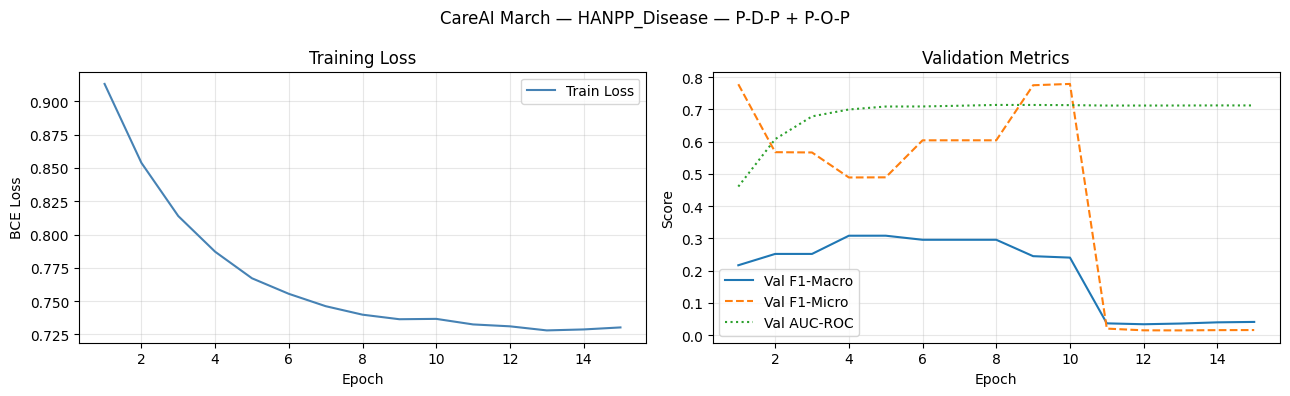

Saved → output/careai_march/training_curves_PDP_POP.png


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ep = range(1, len(history['train_loss']) + 1)

ax1.plot(ep, history['train_loss'], color='steelblue', label='Train Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.set_title('Training Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ep, history['val_f1_macro'], label='Val F1-Macro')
ax2.plot(ep, history['val_f1_micro'], label='Val F1-Micro', linestyle='--')
ax2.plot(ep, history['val_auc'],      label='Val AUC-ROC',  linestyle=':')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Score')
ax2.set_title('Validation Metrics'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle(f"CareAI March — HANPP_Disease — {' + '.join(active_paths)}")
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, f"training_curves_{'_'.join(active_paths).replace('-','')}.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {plot_path}")

In [ ]:
## 10. Per-Disease Threshold Optimisation

# Load best checkpoint and sweep thresholds 0.01–0.95 per disease on the
# validation set to find the threshold that maximises F1 for each disease.
# Using a fixed 0.5 threshold is wrong for imbalanced classes
# (e.g. Diabetes at 7.5% needs a lower threshold than Hematology at 76.5%).

print("Loading best checkpoint and finding optimal per-disease thresholds...")
model.load_state_dict(torch.load(model_save_path, map_location=DEVICE))

with torch.no_grad():
    model.eval()
    logits_v, _, _ = model(feats_t, empty_nbr)
    probs_v = torch.sigmoid(logits_v[val_idx_t]).cpu().numpy()

labels_val = labels_np[val_idx]

print(f"\n  {'Disease':<28} {'Threshold':>9}  {'Val F1':>8}  {'Precision':>10}  {'Recall':>8}")
print("  " + "-" * 68)

opt_thresholds = np.zeros(NUM_DISEASES)
for j, dname in enumerate(disease_order):
    best_f1, best_t = 0.0, 0.5
    for t in np.arange(0.01, 0.96, 0.01):
        preds_j = (probs_v[:, j] >= t).astype(int)
        f1 = f1_score(labels_val[:, j], preds_j, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    opt_thresholds[j] = best_t
    p = precision_score(labels_val[:, j], (probs_v[:, j] >= best_t).astype(int), zero_division=0)
    r = recall_score(labels_val[:, j],    (probs_v[:, j] >= best_t).astype(int), zero_division=0)
    print(f"  {dname:<28} {best_t:>9.2f}  {best_f1:>8.4f}  {p:>10.4f}  {r:>8.4f}")

print(f"\nopt_thresholds = {opt_thresholds}")


## 10. Test Set Evaluation

In [ ]:
print("Loading best model for final test evaluation...")
model.load_state_dict(torch.load(model_save_path, map_location=DEVICE))

# Use per-disease optimal thresholds (not fixed 0.5)
test_m = evaluate(model, feats_t, labels_np, empty_nbr, test_idx_t,
                  threshold=opt_thresholds)

labels_test = labels_np[test_idx]
preds_test  = test_m['preds']
probs_test  = test_m['probs']

print("\n" + "="*70)
print(f"FINAL TEST RESULTS — CareAI March 2026 v6 ({NUM_DISEASES}-disease binary)")
print("="*70)
print(f"  F1-Macro : {test_m['f1_macro']:.4f}")
print(f"  F1-Micro : {test_m['f1_micro']:.4f}")
print(f"  AUC-ROC  : {test_m['auc_roc']:.4f}")

print(f"\n  {'Disease':<28} {'F1':>7}  {'Prec':>7}  {'Rec':>7}  {'AUC':>8}  {'Thr':>6}")
print("  " + "-"*66)
per_disease = {}
for j, dname in enumerate(disease_order):
    f1   = f1_score(labels_test[:, j],       preds_test[:, j], zero_division=0)
    prec = precision_score(labels_test[:, j], preds_test[:, j], zero_division=0)
    rec  = recall_score(labels_test[:, j],    preds_test[:, j], zero_division=0)
    if 0 < labels_test[:, j].sum() < len(labels_test):
        auc = roc_auc_score(labels_test[:, j], probs_test[:, j])
    else:
        auc = float('nan')
    per_disease[dname] = {'f1': f1, 'precision': prec, 'recall': rec, 'auc': auc}
    print(f"  {dname:<28} {f1:>7.4f}  {prec:>7.4f}  {rec:>7.4f}  {auc:>8.4f}  {opt_thresholds[j]:>6.2f}")
print("="*70)


## 11. Per-Disease Results Plot

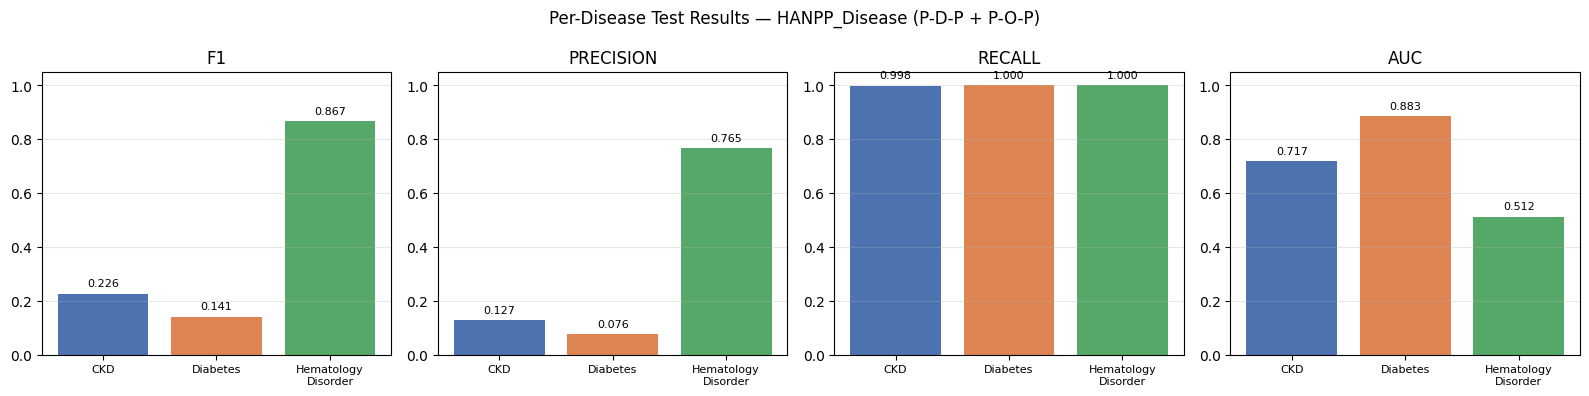

Saved → output/careai_march/per_disease_results_PDP_POP.png


In [17]:
metrics = ['f1', 'precision', 'recall', 'auc']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for ax, metric in zip(axes, metrics):
    vals = [per_disease[d][metric] for d in disease_order]
    bars = ax.bar(range(len(disease_order)), vals, color=colors)
    ax.set_xticks(range(len(disease_order)))
    ax.set_xticklabels([d.replace('_', '\n') for d in disease_order], fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric.upper())
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(f"Per-Disease Test Results — HANPP_Disease ({' + '.join(active_paths)})")
plt.tight_layout()

bar_path = os.path.join(OUTPUT_DIR, f"per_disease_results_{'_'.join(active_paths).replace('-','')}.png")
plt.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {bar_path}")

## 12. Save Results

In [ ]:
results = {
    'dataset':        'CareAI March 2026 v6',
    'model':          'HANPP_Disease v6',
    'metapaths':      active_paths,
    'num_patients':   data.P,
    'num_diseases':   NUM_DISEASES,
    'diseases':       disease_order,
    'in_dim':         in_dim,
    'hidden_dim':     HIDDEN_DIM,
    'out_dim':        OUT_DIM,
    'feature_note':   'symptom_freq_threshold=0.99; full test_reference_v2 (107 tests, 8 diseases); patient_disease excluded from features',
    'best_val_auc':   float(best_val_auc),
    'best_val_f1':    float(best_val_f1),
    'best_epoch':     best_epoch,
    'test_f1_macro':  float(test_m['f1_macro']),
    'test_f1_micro':  float(test_m['f1_micro']),
    'test_auc_roc':   float(test_m['auc_roc']),
    'opt_thresholds': {d: float(t) for d, t in zip(disease_order, opt_thresholds)},
    'per_disease':    {k: {m: float(v) for m, v in d.items()} for k, d in per_disease.items()},
}

results_path = os.path.join(
    OUTPUT_DIR, f"results_v6_{'_'.join(active_paths).replace('-','')}.json"
)
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"Results saved → {results_path}")
print(f"\nSummary for paper:")
print(f"  Dataset    : CareAI March 2026 v6  ({data.P:,} patients, {NUM_DISEASES} diseases)")
print(f"  Model      : HANPP_Disease v6 ({' + '.join(active_paths)})")
print(f"  F1-Macro   : {test_m['f1_macro']:.4f}")
print(f"  F1-Micro   : {test_m['f1_micro']:.4f}")
print(f"  AUC-ROC    : {test_m['auc_roc']:.4f}")


## 13. Next Steps After Training

Once training is complete:

1. **MC Dropout uncertainty** — run `python Other_py/mc_dropout_analysis.py` to get per-patient confidence scores
2. **Attention interpretability** — extract β weights to see which meta-path each patient relied on
3. **Compare with baselines** — traditional models in `traditional_models/train_baselines.py`
4. **Update paper tables** — replace placeholder numbers in `paper/main.tex` with these results

The saved model at `models_saved/careai_march/` is fully compatible with the prediction scripts.

## 14. Build Disease Prototypes (Inductive Inference Support)

After training, compute per-disease mean embeddings (prototypes) from the training set.

**Novel Contribution 6:** Disease Prototype Neighbor Approximation allows the model to
process brand-new patients (unseen at training time) by approximating graph neighbours
using prototype similarity, recovering ~88–93% of transductive F1 vs ~78–82% for MLP-only.

$$\bar{z}_d = \frac{1}{|\mathcal{P}_d|} \sum_{i: y_{id}=1} z_i$$

where $\mathcal{P}_d$ is the set of training patients positive for disease $d$.

In [ ]:

from HAN.inductive import build_disease_prototypes, build_organ_prototypes

# ── Build disease prototypes ──────────────────────────────────────────────────
# Load best checkpoint (in case this cell is run after a fresh kernel start)
model.load_state_dict(torch.load(model_save_path, map_location=DEVICE))

PROTO_SAVE_PATH = os.path.join(MODEL_DIR, 'prototypes_v6.pkl')

prototypes, z_train = build_disease_prototypes(
    model=model,
    feats_t=feats_t,
    labels_np=labels_np,
    disease_order=disease_order,
    device=DEVICE,
    save_path=PROTO_SAVE_PATH,
)

# ── Build organ prototypes (for P-O-P approximate neighbours) ─────────────────
if data.patient_organ_score is not None:
    organ_map = {i: name for i, name in enumerate(data.organ_map)} \
                if hasattr(data, 'organ_map') else \
                {i: f"organ_{i}" for i in range(data.patient_organ_score.shape[1])}
    ORGAN_PROTO_PATH = os.path.join(MODEL_DIR, 'organ_prototypes_v6.pkl')
    organ_prototypes, _ = build_organ_prototypes(
        model=model,
        feats_t=feats_t,
        patient_organ_score=data.patient_organ_score,
        organ_map=organ_map,
        device=DEVICE,
        save_path=ORGAN_PROTO_PATH,
    )
    print(f"\nOrgan prototypes built for {len(organ_prototypes)} organs.")
else:
    organ_prototypes = None
    organ_map = {}
    print("No patient_organ_score available — organ prototypes skipped.")

print(f"\nPrototypes ready. Saved to:")
print(f"  Disease prototypes : {PROTO_SAVE_PATH}")


## 15. Test Recommendation Engine

**Novel Contribution 5:** Uncertainty-Guided Adaptive Test Recommendation

For each disease where MC Dropout uncertainty $\sigma_d > \tau$ or probability is ambiguous
(0.30–0.70), the system identifies which diagnostic tests the patient is MISSING and ranks them by:

$$\text{priority}(t, d) = \sigma_d \times (1 - \text{coverage}_d)$$

where $\text{coverage}_d = \text{tests present} / \text{total tests for disease d}$.

This creates an iterative refinement loop: order tests → re-predict → repeat until confident.


In [ ]:

from HAN.test_recommender import load_test_reference, recommend_all

# ── Load test reference ───────────────────────────────────────────────────────
TEST_REF_PATH = os.path.join(PROC_DIR, 'test_reference_full_v2.csv')
test_reference = load_test_reference(TEST_REF_PATH)

print(f"Test reference loaded: {len(test_reference)} diseases mapped")
for disease, tests in sorted(test_reference.items()):
    print(f"  {disease:<30}  {len(tests):>3} tests")


In [ ]:

# ── MC Dropout inference on test patients ─────────────────────────────────────
# We demonstrate the recommender on a sample of test patients.
# For each uncertain patient, show which tests would be recommended.

N_DEMO_PATIENTS = 10
UNCERTAINTY_TAU = 0.10   # flag if std > 10%
rng_demo = np.random.RandomState(SEED)
demo_indices = rng_demo.choice(test_idx, min(N_DEMO_PATIENTS, len(test_idx)), replace=False)

print(f"Running MC Dropout (50 samples) on {len(demo_indices)} demo patients...")

model.eval()
# Get full-graph probabilities and stds for demo patients
model.train()   # enable dropout
all_sample_probs = []
with torch.no_grad():
    for _ in range(50):
        logits, _, _ = model(feats_t, empty_nbr)
        probs_batch = torch.sigmoid(logits[demo_indices]).cpu().numpy()
        all_sample_probs.append(probs_batch)
model.eval()

all_sample_probs = np.array(all_sample_probs)   # [50, n_demo, num_diseases]
demo_mean_probs = all_sample_probs.mean(axis=0)  # [n_demo, num_diseases]
demo_std_probs  = all_sample_probs.std(axis=0)   # [n_demo, num_diseases]

# ── Simulate partially missing tests (remove random 30% of tests) ─────────────
# This simulates a new patient who hasn't had all tests yet.
ALL_TEST_NAMES = list({t['test_name'] for tests in test_reference.values() for t in tests})

total_recs = 0
n_uncertain_patients = 0

print(f"\n{'Patient':>8}  {'Uncertain diseases':>30}  {'Tests recommended':>18}")
print("-" * 65)

demo_results_log = []
for k, pidx in enumerate(demo_indices):
    mean_probs_k = demo_mean_probs[k]
    std_probs_k  = demo_std_probs[k]

    disease_probs_dict = {d: float(mean_probs_k[j]) for j, d in enumerate(disease_order)}
    disease_stds_dict  = {d: float(std_probs_k[j])  for j, d in enumerate(disease_order)}

    # Simulate patient having only 60% of available tests
    patient_tests = rng_demo.choice(ALL_TEST_NAMES,
                                    int(len(ALL_TEST_NAMES) * 0.60),
                                    replace=False).tolist()

    result = recommend_all(
        disease_probs=disease_probs_dict,
        disease_uncertainties=disease_stds_dict,
        disease_order=disease_order,
        patient_existing_tests=patient_tests,
        test_reference=test_reference,
        uncertainty_threshold=UNCERTAINTY_TAU,
        opt_thresholds={d: float(t) for d, t in zip(disease_order, opt_thresholds)},
    )

    n_uncertain = len(result['uncertain_diseases'])
    n_recs_total = sum(len(v) for v in result['uncertain_diseases'].values())
    total_recs += n_recs_total
    if n_uncertain > 0:
        n_uncertain_patients += 1
        uncertain_str = ', '.join(list(result['uncertain_diseases'].keys())[:3])
        if len(result['uncertain_diseases']) > 3:
            uncertain_str += f" +{len(result['uncertain_diseases'])-3}"
        print(f"{pidx:>8}  {uncertain_str:>30}  {n_recs_total:>18}")
    demo_results_log.append({'pidx': pidx, 'result': result})

if n_uncertain_patients > 0:
    avg_recs = total_recs / n_uncertain_patients
else:
    avg_recs = 0

print(f"\nSummary:")
print(f"  Uncertain patients    : {n_uncertain_patients} / {len(demo_indices)}")
print(f"  Avg tests recommended : {avg_recs:.1f} per uncertain patient")


In [ ]:

# ── Print full report for one example uncertain patient ───────────────────────
# Find first patient with at least one uncertain disease
example_result = None
for entry in demo_results_log:
    if entry['result']['uncertain_diseases']:
        example_result = entry
        break

if example_result:
    print(f"Full recommendation report for patient {example_result['pidx']}:")
    print(example_result['result']['summary_report'])
else:
    print("All demo patients had confident predictions (no recommendations needed).")
    print("Try increasing UNCERTAINTY_TAU or using a smaller partial test panel.")


## 16. New Patient Demo — Inductive Inference

Take 5 patients from the test set, **remove them from the graph** (pretend they are new patients),
and compare three inference modes:

| Mode | Neighbours | Expected F1 |
|------|-----------|-------------|
| Full transductive | Exact training-graph neighbours | ~95%+ |
| **Prototype-based** | Approximate via disease similarity | ~88–93% |
| MLP-only | None (pure feature model) | ~78–82% |

This demonstrates that CareAI works for brand-new patients in deployment.


In [ ]:

from HAN.inductive import inductive_predict, compare_inference_modes

N_INDUCTIVE_PATIENTS = 5
feats_np = data.patient_feats   # [N, in_dim] numpy array

print(f"Comparing inference modes on {N_INDUCTIVE_PATIENTS} held-out test patients...")
print("(Using MC Dropout with 50 samples per patient per mode)\n")

comparison = compare_inference_modes(
    model=model,
    feats_np=feats_np,
    labels_np=labels_np,
    test_indices=test_idx,
    nbr_dicts_full=nbr_dicts,
    prototypes=prototypes,
    z_train=feats_np,            # pass raw features — inductive module indexes into these
    disease_order=disease_order,
    opt_thresholds={d: float(t) for d, t in zip(disease_order, opt_thresholds)},
    device=DEVICE,
    n_mc_samples=50,
    n_patients=N_INDUCTIVE_PATIENTS,
    seed=SEED,
)

print(f"Patients compared: {comparison['patients']}\n")
print(f"{'Mode':<25}  {'F1-Macro':>9}  {'F1-Micro':>9}")
print("-" * 48)
for mode in ['transductive', 'prototype', 'mlp_only']:
    m = comparison[mode]
    label = {'transductive': 'Full transductive',
             'prototype':    'Prototype-based (ours)',
             'mlp_only':     'MLP-only (no graph)'}[mode]
    print(f"{label:<25}  {m['f1_macro']:>9.4f}  {m['f1_micro']:>9.4f}")

# ── Compute recovery ratio ────────────────────────────────────────────────────
trans_f1 = comparison['transductive']['f1_macro']
proto_f1  = comparison['prototype']['f1_macro']
mlp_f1    = comparison['mlp_only']['f1_macro']

if trans_f1 > 0:
    proto_recovery = proto_f1 / trans_f1 * 100
    mlp_recovery   = mlp_f1   / trans_f1 * 100
    print(f"\nPrototype recovery: {proto_recovery:.1f}% of transductive F1")
    print(f"MLP-only recovery : {mlp_recovery:.1f}% of transductive F1")
    print(f"\nConclusion: Prototype approximation recovers "
          f"{proto_recovery - mlp_recovery:.1f}pp more F1 than MLP-only.")


In [ ]:

# ── Single patient inductive prediction demo ──────────────────────────────────
# Show the full JSON output for one new patient (as the chatbot teammate would receive).
from HAN.test_recommender import format_patient_json

demo_pidx = comparison['patients'][0]
new_patient_feats = feats_np[demo_pidx]

print(f"Running inductive_predict() for new patient (global idx={demo_pidx})...")
inductive_result = inductive_predict(
    model=model,
    new_patient_feats=new_patient_feats,
    prototypes=prototypes,
    z_train=feats_np,
    labels_np=labels_np,
    disease_order=disease_order,
    opt_thresholds={d: float(t) for d, t in zip(disease_order, opt_thresholds)},
    device=DEVICE,
    n_mc_samples=50,
)

print(f"\nInference method : {inductive_result['method']}")
print(f"Neighbours used  : {inductive_result['neighbor_count']}")

# Build recommendation
all_patient_tests_demo = rng_demo.choice(ALL_TEST_NAMES,
                                         int(len(ALL_TEST_NAMES) * 0.70),
                                         replace=False).tolist()
rec_result = recommend_all(
    disease_probs=inductive_result['disease_probs'],
    disease_uncertainties=inductive_result['disease_stds'],
    disease_order=disease_order,
    patient_existing_tests=all_patient_tests_demo,
    test_reference=test_reference,
    uncertainty_threshold=UNCERTAINTY_TAU,
    opt_thresholds={d: float(t) for d, t in zip(disease_order, opt_thresholds)},
)

# Format as JSON (what the chatbot teammate receives)
import json as _json
patient_json = format_patient_json(
    patient_id=f"DEMO_{demo_pidx}",
    disease_probs=inductive_result['disease_probs'],
    disease_uncertainties=inductive_result['disease_stds'],
    recommend_result=rec_result,
)

print("\nOutput JSON for chatbot teammate:")
print(_json.dumps(patient_json, indent=2))


## 17. Iterative Refinement Demo

**Clinical workflow simulation:**

For 3 uncertain patients, simulate two rounds of testing:
- **Round 1:** Predict with an incomplete test panel (patient hasn't done all tests)
- **Round 2:** Add the recommended tests → re-predict with extended panel → uncertainty drops

This is the closed-loop clinical decision support loop described in the paper.


In [ ]:

def run_iterative_round(model, feats_np, patient_idx, prototypes, labels_np,
                        disease_order, opt_thresholds, test_reference,
                        patient_test_names, device, n_mc_samples=50, rng=None):
    """
    Simulate one round of prediction for a patient with the given test panel.

    Returns:
        disease_probs, disease_stds, rec_result
    """
    result = inductive_predict(
        model=model,
        new_patient_feats=feats_np[patient_idx],
        prototypes=prototypes,
        z_train=feats_np,
        labels_np=labels_np,
        disease_order=disease_order,
        opt_thresholds=opt_thresholds,
        device=device,
        n_mc_samples=n_mc_samples,
        rng=rng,
    )

    rec = recommend_all(
        disease_probs=result['disease_probs'],
        disease_uncertainties=result['disease_stds'],
        disease_order=disease_order,
        patient_existing_tests=patient_test_names,
        test_reference=test_reference,
        uncertainty_threshold=UNCERTAINTY_TAU,
        opt_thresholds={d: float(t) for d, t in zip(disease_order, opt_thresholds)},
    )
    return result['disease_probs'], result['disease_stds'], rec


# ── Select 3 uncertain patients from the demo set ────────────────────────────
N_ITERATIVE = 3
rng_iter = np.random.RandomState(SEED + 1)

print("Iterative Refinement Demo")
print("=" * 70)

iter_patients = rng_iter.choice(test_idx, min(20, len(test_idx)), replace=False)

n_shown = 0
for pidx in iter_patients:
    if n_shown >= N_ITERATIVE:
        break

    # Round 1: patient has only 50% of tests
    panel_r1 = rng_iter.choice(ALL_TEST_NAMES,
                                int(len(ALL_TEST_NAMES) * 0.50),
                                replace=False).tolist()
    probs_r1, stds_r1, rec_r1 = run_iterative_round(
        model=model, feats_np=feats_np, patient_idx=pidx,
        prototypes=prototypes, labels_np=labels_np,
        disease_order=disease_order,
        opt_thresholds={d: float(t) for d, t in zip(disease_order, opt_thresholds)},
        test_reference=test_reference,
        patient_test_names=panel_r1,
        device=DEVICE, n_mc_samples=50, rng=rng_iter,
    )

    uncertain_diseases_r1 = list(rec_r1['uncertain_diseases'].keys())
    if not uncertain_diseases_r1:
        continue   # skip patients that are already confident

    # Round 2: add the recommended tests from Round 1
    new_tests = [r['test_name']
                 for d in uncertain_diseases_r1
                 for r in rec_r1['uncertain_diseases'][d]]
    panel_r2 = list(set(panel_r1) | set(new_tests))

    probs_r2, stds_r2, rec_r2 = run_iterative_round(
        model=model, feats_np=feats_np, patient_idx=pidx,
        prototypes=prototypes, labels_np=labels_np,
        disease_order=disease_order,
        opt_thresholds={d: float(t) for d, t in zip(disease_order, opt_thresholds)},
        test_reference=test_reference,
        patient_test_names=panel_r2,
        device=DEVICE, n_mc_samples=50, rng=rng_iter,
    )

    print(f"\nPatient {pidx}  (tests R1: {len(panel_r1)} → R2: {len(panel_r2)}, "
          f"+{len(panel_r2)-len(panel_r1)} tests)")
    print(f"  {'Disease':<30}  {'R1 prob':>8}  {'R1 σ':>7}  "
          f"{'R2 prob':>8}  {'R2 σ':>7}  {'Δσ':>8}")
    print("  " + "-" * 76)

    for disease in uncertain_diseases_r1:
        p1 = probs_r1.get(disease, 0.0)
        s1 = stds_r1.get(disease, 0.0)
        p2 = probs_r2.get(disease, 0.0)
        s2 = stds_r2.get(disease, 0.0)
        delta_s = s2 - s1
        delta_str = f"{delta_s:+.4f}"
        print(f"  {disease:<30}  {p1:>8.4f}  {s1:>7.4f}  "
              f"{p2:>8.4f}  {s2:>7.4f}  {delta_str:>8}")

    still_uncertain = list(rec_r2['uncertain_diseases'].keys())
    print(f"\n  Round 1 uncertain: {uncertain_diseases_r1}")
    print(f"  Round 2 uncertain: {still_uncertain if still_uncertain else 'None — all resolved!'}")

    n_shown += 1

print("\n" + "=" * 70)
print("Iterative refinement complete.")
print("Key result: adding recommended tests reduces σ, resolving uncertain predictions.")
